In [1]:
import shutil
shutil.rmtree("/tmp/tfcache", ignore_errors=True)

In [2]:
import os
import random
import numpy as np
import librosa
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, confusion_matrix,ConfusionMatrixDisplay, f1_score, roc_curve)


2026-06-07 23:18:11.294669: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780874291.537666      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780874291.601814      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780874292.230755      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780874292.230818      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780874292.230821      16 computation_placer.cc:177] computation placer alr

In [3]:
import tensorflow as tf


gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {gpus}")

if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Using GPU: {gpus[0].name}")
else:
    print("No GPU found, running on CPU")

GPUs available: []
No GPU found, running on CPU


2026-06-07 23:18:44.228179: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


# Reconocimiento de audio

In [4]:
SR = 22050
N_FFT = 2048
HOP = 512
N_MELS = 128
MAX_LEN = 128
TARGET_SECONDS = 3.0
TARGET_SAMPLES = int(SR * TARGET_SECONDS)
 
MEL_MATRIX = tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins=N_MELS,
    num_spectrogram_bins=N_FFT // 2 + 1,
    sample_rate=SR,
    lower_edge_hertz=0.0,
    upper_edge_hertz=SR / 2,
)

# Creacion de Mel Spectogram

In [5]:
@tf.function(input_signature=[tf.TensorSpec(shape=[None], dtype=tf.float32)])
def tf_mel_spectrogram(waveform):
    stft = tf.signal.stft(
        waveform,
        frame_length=N_FFT,
        frame_step=HOP,
        fft_length=N_FFT,
        window_fn=tf.signal.hann_window,
    )
    power = tf.abs(stft) ** 2
    mel = tf.matmul(power, MEL_MATRIX)
    mel_db = 10.0 * (tf.math.log(mel + 1e-6) / tf.math.log(10.0))
    mel_db = mel_db - tf.reduce_max(mel_db) 
    mel_db = tf.maximum(mel_db, -80.0)
    mel_db = tf.transpose(mel_db)
    frames = tf.shape(mel_db)[1]
    mel_db = tf.cond(
        frames < MAX_LEN,
        lambda: tf.pad(mel_db, [[0, 0], [0, MAX_LEN - frames]],
                       constant_values=-80.0),    
        lambda: mel_db[:, :MAX_LEN],
    )
    mel_db.set_shape([N_MELS, MAX_LEN])
    mel_db = tf.ensure_shape(mel_db, [N_MELS, MAX_LEN]) 
    return mel_db
 
 
def _load_fixed_waveform(path):
    path = path.decode("utf-8") if isinstance(path, (bytes, np.bytes_)) else str(path)
    w, _ = librosa.load(path, sr=SR, mono=True)
    if w.size > 0:
        trimmed, _ = librosa.effects.trim(w, top_db=30)
        if trimmed.size > 0:                          # que no se quede vacio despues del trimm
            w = trimmed
    if w.size == 0:                                   # vacio
        return np.zeros(TARGET_SAMPLES, dtype=np.float32)
    peak = np.max(np.abs(w))
    if peak > 0:
        w = w / peak
    if w.size >= TARGET_SAMPLES:
        w = w[:TARGET_SAMPLES]
    else:
        w = np.pad(w, (0, TARGET_SAMPLES - w.size))
    return w.astype(np.float32)

def load_waveform(path, label):
    w = tf.numpy_function(_load_fixed_waveform, [path], tf.float32)
    w.set_shape([TARGET_SAMPLES])
    return w, label

# Ceacion de divisones test, train, y split usando las divisones del dataset

In [6]:
AUDIO_EXTS = ('.wav', '.mp3', '.flac', '.ogg')
SPLITS = ('training', 'validation', 'testing')

NORM_DIR  = '/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-norm' 
REREC_DIR = '/kaggle/input/datasets/mohammedabdeldayem/the-fake-or-real-dataset/for-rerec'

def collect_version(base_dir):
    real, fake = [], []
    for dp, _, fns in os.walk(base_dir):
        low = dp.lower() + os.sep
        if   os.sep + 'real' + os.sep in low: bucket = real
        elif os.sep + 'fake' + os.sep in low: bucket = fake
        else: continue
        for fn in fns:
            if fn.lower().endswith(AUDIO_EXTS):
                bucket.append(os.path.join(dp, fn))
    return real, fake

norm_real,  norm_fake  = collect_version(NORM_DIR)
rerec_real, rerec_fake = collect_version(REREC_DIR)

rng = random.Random(42)
rng.shuffle(norm_real); rng.shuffle(norm_fake)

def split2(p, val=0.10):
    k = int(len(p) * (1 - val)); return p[:k], p[k:]

train_real, val_real = split2(norm_real)  
train_fake, val_fake = split2(norm_fake)
test_real,  test_fake = rerec_real, rerec_fake   # testear con una parte diferente del dataset a la que se entreno (rerec)

print(f"Train {len(train_real)}/{len(train_fake)} | Val {len(val_real)}/{len(val_fake)} | Test(rerec) {len(test_real)}/{len(test_fake)}")


Train 31144/31225 | Val 3461/3470 | Test(rerec) 6613/6655


# Crear data pipeline

In [7]:
AUTOTUNE = tf.data.AUTOTUNE
SNR_MIN, SNR_MAX = 5.0, 25.0          
LP_MIN,  LP_MAX  = 0.5, 1.0           
REVERB_LEN = 1500                     
FREQ_MASK_MAX, N_FREQ_MASKS = 16, 2
TIME_MASK_MAX, N_TIME_MASKS = 16, 2

def _add_noise(w):
    snr = tf.random.uniform([], SNR_MIN, SNR_MAX)
    sig = tf.reduce_mean(w ** 2) + 1e-9
    npow = sig / (10.0 ** (snr / 10.0))
    return w + tf.random.normal(tf.shape(w)) * tf.sqrt(npow)

def _bandlimit(w):
    cutoff = tf.random.uniform([], LP_MIN, LP_MAX)
    W = tf.signal.rfft(w, fft_length=[TARGET_SAMPLES])
    nb = TARGET_SAMPLES // 2 + 1
    keep = tf.cast(tf.round(tf.cast(nb, tf.float32) * cutoff), tf.int32)
    mask = tf.concat([tf.ones([keep]), tf.zeros([nb - keep])], 0)
    out = tf.signal.irfft(W * tf.cast(mask, tf.complex64), fft_length=[TARGET_SAMPLES])
    out.set_shape([TARGET_SAMPLES]); return out

def _reverb(w):
    t = tf.range(REVERB_LEN, dtype=tf.float32) / tf.cast(SR, tf.float32)
    rt = tf.random.uniform([], 0.1, 0.4)
    ir = tf.exp(-t / rt) * tf.random.normal([REVERB_LEN])
    ir = ir / (tf.norm(ir) + 1e-9)
    w4 = tf.pad(tf.reshape(w, [1, -1, 1]), [[0, 0], [REVERB_LEN - 1, 0], [0, 0]])
    k = tf.reshape(ir[::-1], [REVERB_LEN, 1, 1])
    out = tf.reshape(tf.nn.conv1d(w4, k, stride=1, padding="VALID"), [-1])[:TARGET_SAMPLES]
    out.set_shape([TARGET_SAMPLES]); return out

def _maybe(w, fn, p):
    return tf.cond(tf.random.uniform([]) < p, lambda: fn(w), lambda: w)

def augment_waveform(w):
    w = _maybe(w, _add_noise, 0.6)
    w = _maybe(w, _bandlimit, 0.4)
    w = _maybe(w, _reverb,   0.3)
    w.set_shape([TARGET_SAMPLES]); return w

def _mask_axis(spec, axis_len, max_width, axis):
    wd = tf.random.uniform([], 0, max_width + 1, dtype=tf.int32)
    start = tf.random.uniform([], 0, axis_len - wd + 1, dtype=tf.int32)
    idx = tf.range(axis_len)
    keep = tf.cast(tf.logical_or(idx < start, idx >= start + wd), spec.dtype)
    keep = tf.reshape(keep, [axis_len, 1, 1] if axis == 0 else [1, axis_len, 1])
    return spec * keep + (1.0 - keep) * (-80.0)

def spec_augment(mel):
    for _ in range(N_FREQ_MASKS): mel = _mask_axis(mel, N_MELS, FREQ_MASK_MAX, 0)
    for _ in range(N_TIME_MASKS): mel = _mask_axis(mel, MAX_LEN, TIME_MASK_MAX, 1)
    return mel

def train_map(w, label):
    mel = tf.expand_dims(tf_mel_spectrogram(augment_waveform(w)), -1)
    mel = spec_augment(mel)
    mel.set_shape([N_MELS, MAX_LEN, 1]); return mel, label

def eval_map(w, label):
    mel = tf.expand_dims(tf_mel_spectrogram(w), -1)
    mel.set_shape([N_MELS, MAX_LEN, 1]); return mel, label

In [8]:
BATCH_SIZE = 32

def make_ds(real_paths, fake_paths, training):
    paths  = real_paths + fake_paths
    labels = [1] * len(real_paths) + [0] * len(fake_paths)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_waveform, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(len(paths), reshuffle_each_iteration=True)
        ds = ds.map(train_map, num_parallel_calls=AUTOTUNE)        # Aumentacion cada epoca
        return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    ds = ds.map(eval_map, num_parallel_calls=AUTOTUNE).cache()
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_ds(train_real, train_fake, training=True)
val_ds   = make_ds(val_real,   val_fake,   training=False)
test_ds  = make_ds(test_real,  test_fake,  training=False)

# Creacion y entrenamiento del modelo

In [9]:
POOLS = 3
F = N_MELS // (2 ** POOLS)
T = MAX_LEN // (2 ** POOLS)
LAST_FILTERS = 128

## Modelo CNN + BiLSTM con 10 capas

In [10]:
class PerSampleStandardization(layers.Layer):
    def call(self, x):
        mean = tf.reduce_mean(x, axis=[1, 2, 3], keepdims=True)
        std  = tf.math.reduce_std(x, axis=[1, 2, 3], keepdims=True)
        return (x - mean) / (std + 1e-6)

In [11]:
def build_model():
    model = keras.Sequential([
        keras.Input((N_MELS, MAX_LEN, 1)),
        PerSampleStandardization(),

        layers.Conv2D(32, 3, padding="same"),
        layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(2), layers.SpatialDropout2D(0.1),

        layers.Conv2D(64, 3, padding="same"),
        layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(2), layers.SpatialDropout2D(0.1),

        layers.Conv2D(LAST_FILTERS, 3, padding="same"),
        layers.BatchNormalization(), layers.ReLU(),
        layers.MaxPooling2D(2), layers.SpatialDropout2D(0.1),

        layers.Permute((2, 1, 3)),
        layers.Reshape((T, F * LAST_FILTERS)),

        layers.Bidirectional(layers.LSTM(64, return_sequences=True)),
        layers.Dropout(0.3),
        layers.Bidirectional(layers.LSTM(32)),

        layers.Dense(64, activation="relu"),
        layers.Dropout(0.4),
        layers.Dense(1, activation="sigmoid"),
    ])
    return model

model = build_model()
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-4),
    loss=keras.losses.BinaryCrossentropy(label_smoothing=0.05),
    metrics=["accuracy",
             keras.metrics.Precision(name="precision"),
             keras.metrics.Recall(name="recall"),
             keras.metrics.AUC(name="auc")],
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ per_sample_standardization      │ (None, 128, 128, 1)    │             0 │
│ (PerSampleStandardization)      │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 64, 64, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 32, 32, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_2             │ (None, 16, 16, 128)    │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 16, 2048)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 16, 128)        │     1,081,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,220,865 (4.66 MB)

 Trainable params: 1,220,417 (4.66 MB)

 Non-trainable params: 448 (1.75 KB)

## Pesos de clase para arregla desbalance en el dataset

In [12]:
n_real, n_fake = len(train_real), len(train_fake)
total = n_real + n_fake
class_weight = {0: total / (2 * n_fake), 1: total / (2 * n_real)}
print("class_weight:", class_weight)

class_weight: {0: 0.9987029623698959, 1: 1.001300410994092}


## Entrenamiento


In [13]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "checkpoint_{epoch}.keras")

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_prefix,
        save_weights_only=False,
        save_freq="epoch",
        save_best_only=True
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max",
        patience=5, restore_best_weights=True,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5,
        patience=3, min_lr=1e-5,
    ),
]
 
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks,
)

Epoch 1/15
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 2799s 1s/step - accuracy: 0.8049 - auc: 0.8694 - loss: 0.4739 - precision: 0.8047 - recall: 0.8065 - val_accuracy: 0.9139 - val_auc: 0.9747 - val_loss: 0.2916 - val_precision: 0.9540 - val_recall: 0.8694 - learning_rate: 1.0000e-04
Epoch 2/15
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 2737s 1s/step - accuracy: 0.8866 - auc: 0.9499 - loss: 0.3383 - precision: 0.8931 - recall: 0.8767 - val_accuracy: 0.9719 - val_auc: 0.9964 - val_loss: 0.1767 - val_precision: 0.9642 - val_recall: 0.9801 - learning_rate: 1.0000e-04
Epoch 3/15
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 2805s 1s/step - accuracy: 0.9223 - auc: 0.9726 - loss: 0.2774 - precision: 0.9252 - recall: 0.9191 - val_accuracy: 0.9782 - val_auc: 0.9984 - val_loss: 0.1622 - val_precision: 0.9943 - val_recall: 0.9619 - learning_rate: 1.0000e-04
Epoch 4/15
1950/1950 ━━━━━━━━━━━━━━━━━━━━ 2858s 1s/step - accuracy: 0.9355 - auc: 0.9812 - loss: 0.2494 - precision: 0.9392 - recall: 0.9307 - val_accuracy: 0.9755 - val_auc: 0.9

# Evaluacion del modelo

In [14]:
test_metrics = model.evaluate(test_ds, return_dict=True)
print("Test:", test_metrics)

415/415 ━━━━━━━━━━━━━━━━━━━━ 141s 339ms/step - accuracy: 0.9333 - auc: 0.4810 - loss: 0.2609 - precision: 0.9364 - recall: 0.9748
Test: {'accuracy': 0.8353934288024902, 'auc': 0.9498090147972107, 'loss': 0.4698057472705841, 'precision': 0.7612979412078857, 'recall': 0.9756540060043335}


## Loss por epoca

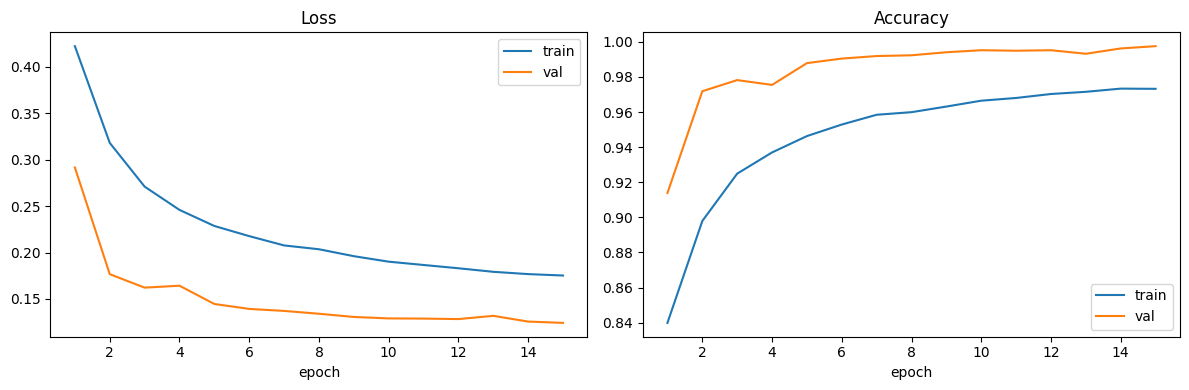

<Figure size 640x480 with 0 Axes>

In [15]:
h = history.history
epochs = range(1, len(h["loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(epochs, h["loss"], label="train")
ax[0].plot(epochs, h["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(epochs, h["accuracy"], label="train")
ax[1].plot(epochs, h["val_accuracy"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()
plt.savefig('loss.png', bbox_inches='tight')



## Predicciones

In [16]:
y_true = np.concatenate([y.numpy() for _, y in test_ds]).astype(int)
y_prob = model.predict(test_ds).ravel()
y_pred = (y_prob >= 0.5).astype(int)

415/415 ━━━━━━━━━━━━━━━━━━━━ 88s 208ms/step


## Precision / recall / F1 / accuracy

In [17]:
print(classification_report(y_true, y_pred, target_names=["fake (0)", "real (1)"], digits=4))
print(f"Macro F1: {f1_score(y_true, y_pred, average='macro'):.4f}")

              precision    recall  f1-score   support

    fake (0)     0.9664    0.6960    0.8092      6655
    real (1)     0.7613    0.9757    0.8552      6613

    accuracy                         0.8354     13268
   macro avg     0.8639    0.8358    0.8322     13268
weighted avg     0.8642    0.8354    0.8322     13268

Macro F1: 0.8322


In [18]:
fpr, tpr, thr = roc_curve(y_true, y_prob)
fnr = 1 - tpr
i = np.nanargmin(np.abs(fnr - fpr))
print(f"EER: {(fpr[i]+fnr[i])/2:.4f} at threshold {thr[i]:.4f}")

val_true = np.concatenate([y.numpy() for _, y in val_ds]).astype(int)
val_prob = model.predict(val_ds).ravel()
ths = np.linspace(0.0, 1.0, 1001)
op_t = ths[int(np.argmax([f1_score(val_true, (val_prob >= t).astype(int), average="macro") for t in ths]))]
print(f"Threshold chosen on val: {op_t:.4f}")
print(classification_report(y_true, (y_prob >= op_t).astype(int),
                            target_names=["fake (0)", "real (1)"], digits=4))

EER: 0.1164 at threshold 0.9177
217/217 ━━━━━━━━━━━━━━━━━━━━ 44s 203ms/step
Threshold chosen on val: 0.2060
              precision    recall  f1-score   support

    fake (0)     0.9805    0.5889    0.7358      6655
    real (1)     0.7049    0.9882    0.8228      6613

    accuracy                         0.7879     13268
   macro avg     0.8427    0.7885    0.7793     13268
weighted avg     0.8431    0.7879    0.7792     13268



## Matriz de confusion

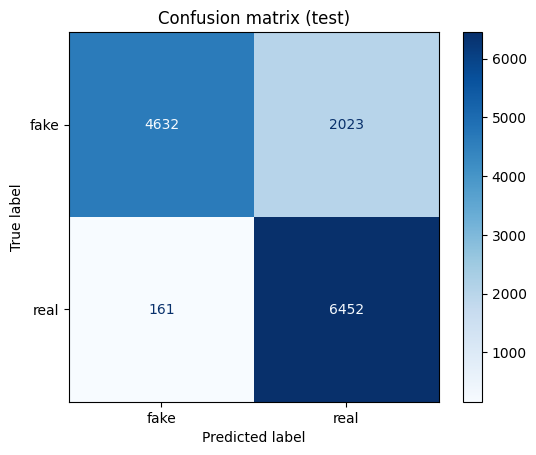

<Figure size 640x480 with 0 Axes>

In [19]:
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["fake", "real"]).plot(
    cmap="Blues", values_format="d")
plt.title("Confusion matrix (test)")
plt.show()
plt.savefig('matriz_confusion.png', bbox_inches='tight')
